## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [3]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [4]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [10]:
## independent feature 
X = df.drop(columns=['math_score'])
## Dependent feature 
y = df['math_score']



In [12]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [13]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [16]:
categorical_cols = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education',
    'lunch',
    'test_preparation_course'
] 
for col in categorical_cols:
    print(f"Categories in '{col}':", df[col].unique().tolist())

Categories in 'gender': ['female', 'male']
Categories in 'race_ethnicity': ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in 'parental_level_of_education': ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch': ['standard', 'free/reduced']
Categories in 'test_preparation_course': ['none', 'completed']


In [14]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [17]:
# Create Column Transformer with 3 types of transformers
num_feature = X.select_dtypes(exclude='str').columns
cat_feature = X.select_dtypes(include='str').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_feature),
        ("StandardScaler",numeric_transformer,num_feature)
    ]
)


In [19]:
X = preprocessor.fit_transform(X)

In [20]:
X.shape

(1000, 19)

In [21]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [29]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate training data
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)

    # Evaluate testing data
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    # Store results
    model_list.append(name)
    r2_list.append(test_r2)

    # Print results
    print(name)

    print("Training Performance")
    print(f"RMSE : {train_rmse:.4f}")
    print(f"MAE  : {train_mae:.4f}")
    print(f"R²   : {train_r2:.4f}")

    print("-" * 40)

    print("Testing Performance")
    print(f"RMSE : {test_rmse:.4f}")
    print(f"MAE  : {test_mae:.4f}")
    print(f"R²   : {test_r2:.4f}")

    print("=" * 50)
    print()


Linear Regression
Training Performance
RMSE : 5.3231
MAE  : 4.2667
R²   : 0.8743
----------------------------------------
Testing Performance
RMSE : 5.3940
MAE  : 4.2148
R²   : 0.8804

Lasso
Training Performance
RMSE : 6.5938
MAE  : 5.2063
R²   : 0.8071
----------------------------------------
Testing Performance
RMSE : 6.5197
MAE  : 5.1579
R²   : 0.8253

Ridge
Training Performance
RMSE : 5.3233
MAE  : 4.2650
R²   : 0.8743
----------------------------------------
Testing Performance
RMSE : 5.3904
MAE  : 4.2111
R²   : 0.8806

K-Neighbors Regressor
Training Performance
RMSE : 5.7079
MAE  : 4.5168
R²   : 0.8555
----------------------------------------
Testing Performance
RMSE : 7.2530
MAE  : 5.6210
R²   : 0.7838

Decision Tree
Training Performance
RMSE : 0.2795
MAE  : 0.0187
R²   : 0.9997
----------------------------------------
Testing Performance
RMSE : 8.0334
MAE  : 6.3950
R²   : 0.7348

Random Forest Regressor
Training Performance
RMSE : 2.3010
MAE  : 1.8388
R²   : 0.9765
------------

In [ ]:
pd.DataFrame(list)

In [36]:
pd.DataFrame(
    list(zip(model_list,r2_list)),
    columns=['Model Name','R2_Score'],
    ).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.853350
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.847032
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.734793


## Linear Regression

In [45]:
del lin_model

In [48]:
lin_model = LinearRegression(n_jobs=-1)
lin_model.fit(X_train,y_train)



,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[-6.53, 6.53,-0.8 ,..., 1.64, 3.44,11. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.52
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](19,)","[40.66,19.81,19.34,..., 0. , 0. , 0. ]"


In [49]:
print("Coefficient or slope:",lin_model.coef_)
print("Intercept",lin_model.intercept_)

Coefficient or slope: [-6.53244193  6.53244193 -0.80262367 -0.44330087 -1.42824083 -1.41585991
  4.09002528 -0.09454143 -0.81144256  0.83477083 -1.49503027  0.90431471
  0.66192873 -1.75503744  1.75503744 -1.64482118  1.64482118  3.44425129
 10.99840031]
Intercept 65.5235765660095


In [50]:
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100 
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


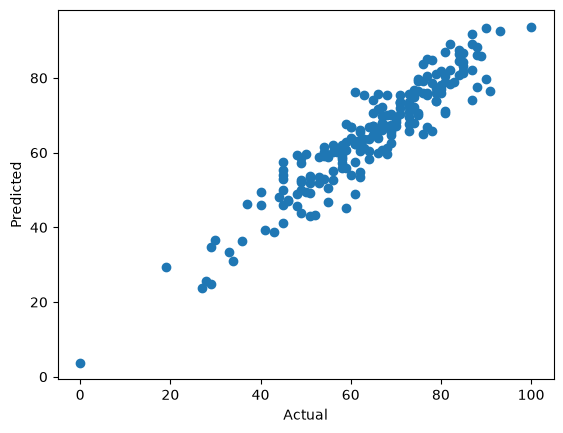

In [52]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

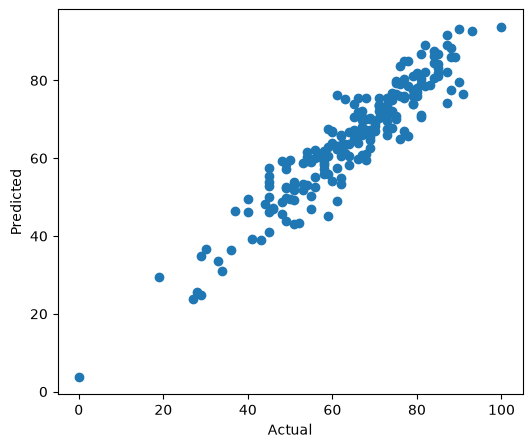

In [53]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [65]:
# regplot stands for Regression Plot.

# It creates two things automatically:

# A scatter plot of your data points.
# A best-fit regression line through those points.

<Axes: xlabel='math_score'>

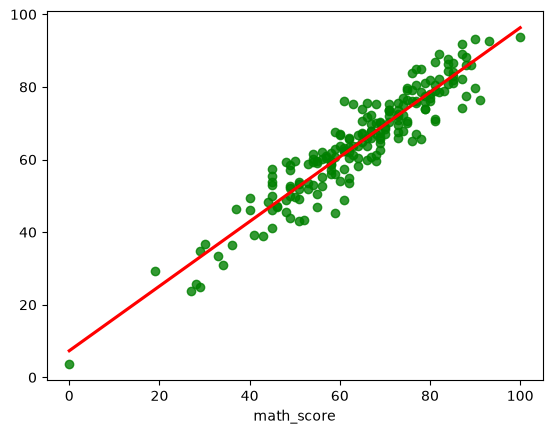

In [64]:
sns.regplot(
    x=y_test,      # actual values (true scores from test set)
    y=y_pred,      # predicted values (model's predictions)
    ci=None,       # no confidence interval band around the line
    scatter_kws={'color': 'green'},   # dots → blue
    line_kws={'color': 'red'}        # line → red
)